# TruthGuard — Notebook 1 : Préparation des données
## Prétraitement NLP · Vectorisation · Features

> **Pipeline de bout-en-bout** : du CSV brut jusqu'aux matrices de features
> prêtes pour la modélisation.
>
> **Contenu** :
> 1. Configuration & Imports
> 2. Chargement du dataset
> 3. Prétraitement NLP (lemmatisation, stopwords, features stylistiques)
> 4. Diagnostics post-nettoyage
> 5. Split Train / Test stratifié
> 6. Export du dataset prétraité
> 7. Vectorisation TF-IDF (word 1-3 + char 2-6)
> 8. Embeddings sémantiques — `all-mpnet-base-v2`
> 9. Features combinées → export `X_train_full`, `X_test_full`


## 1. Configuration & Imports

In [ ]:
import os
import re
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Seed global (reproductibilité) ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Répertoires portables ────────────────────────────────────────────────────
def find_data_dir(csv_name="df_raw_annotated.csv"):
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for root in candidates:
        candidate = root / "notebook" / "Fake_news_net" / "data"
        if (candidate / csv_name).exists():
            return candidate
        candidate = root / "data"
        if (candidate / csv_name).exists():
            return candidate
    raise FileNotFoundError(
        f"Impossible de trouver {csv_name}. Recherche effectuée depuis {cwd} et ses parents."
    )

DATA_DIR = find_data_dir()
CACHE_DIR = DATA_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR  : {DATA_DIR.resolve()}")
print(f"CACHE_DIR : {CACHE_DIR.resolve()}")
print("Configuration prête ✓")


DATA_DIR  : C:\Users\PC\fake-news-app\notebook\ISOT\DATA
CACHE_DIR : C:\Users\PC\fake-news-app\notebook\ISOT\DATA\cache
Configuration prête ✓


In [2]:
import nltk

for resource in ["punkt", "punkt_tab", "stopwords", "wordnet",
                 "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng", "omw-1.4"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

print("Ressources NLTK pretes.")


Ressources NLTK pretes.


## 2. Chargement du dataset

In [4]:
# Adapte ce chemin a ton CSV brut annote

def find_raw_csv(csv_name="df_raw_annotated.csv"):
    cwd = Path.cwd().resolve()
    search_roots = [cwd] + list(cwd.parents)
    for root in search_roots:
        candidates = [
            root / "notebook" / "Fake_news_net" / "data" / csv_name,
            root / "data" / csv_name,
        ]
        for candidate in candidates:
            if candidate.exists():
                return candidate
    raise FileNotFoundError(
        f"Impossible de trouver {csv_name}. Recherche effectuée depuis {cwd} et ses parents."
    )

RAW_CSV = find_raw_csv()
DATA_DIR = RAW_CSV.parent
CACHE_DIR = DATA_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"RAW_CSV    : {RAW_CSV.resolve()}")
print(f"DATA_DIR   : {DATA_DIR.resolve()}")

df_raw = pd.read_csv(RAW_CSV)
print(f"Dimensions brutes : {df_raw.shape}")
print(f"Colonnes          : {list(df_raw.columns)}")
df_raw.head(3)


RAW_CSV    : C:\Users\PC\fake-news-app\notebook\Fake_news_net\data\df_raw_annotated.csv
DATA_DIR   : C:\Users\PC\fake-news-app\notebook\Fake_news_net\data
Dimensions brutes : (422, 7)
Colonnes          : ['label', 'statement', 'source_df', 'char_count', 'word_count', 'sent_count', 'avg_word_len']


,label,statement,source_df,char_count,word_count,sent_count,avg_word_len
0,1,Kaine visits site of Orlando mass shooting Tim...,buzzfeed,1207,200,12,4.920000
1,1,Christie among the most unpopular governors in...,politifact,2033,319,18,5.278997
2,1,McAuliffe hangs with Willie Nelson -- and his ...,buzzfeed,1386,220,9,5.195455


## 3. Prétraitement NLP

Pipeline unifié :
1. Suppression des doublons & NaN
2. Métriques structurelles (word/char/sent count)
3. Filtrage des textes trop courts (< 5 mots)
4. Normalisation (casse, URLs, HTML, ponctuation)
5. Tokenisation NLTK
6. Filtrage stopwords + tokens <= 2 caractères
7. Lemmatisation guidée par POS tags (WordNet)


In [5]:
df = df_raw.copy()
n_avant = len(df)

df.drop_duplicates(subset="statement", inplace=True)
df.dropna(subset=["statement", "label"], inplace=True)

df["word_count"] = df["statement"].str.split().str.len()
df["char_count"] = df["statement"].str.len()
df["sent_count"] = df["statement"].str.split(r"[.!?]+").str.len()

df = df[df["word_count"] >= 5].copy()
df.reset_index(drop=True, inplace=True)

print(f"Avant nettoyage structurel : {n_avant:,}")
print(f"Apres  nettoyage structurel : {len(df):,}  (supprimes : {n_avant - len(df):,})")
print(df["label"].value_counts())


Avant nettoyage structurel : 422
Apres  nettoyage structurel : 289  (supprimes : 133)
label
1    148
0    141
Name: count, dtype: int64


In [6]:
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


def _treebank_to_wordnet(tag: str) -> str:
    mapping = {"J": wordnet.ADJ, "V": wordnet.VERB,
               "N": wordnet.NOUN, "R": wordnet.ADV}
    return mapping.get(tag[0], wordnet.NOUN)


def extract_stylometric_features(text: str) -> dict:
    """Features structurelles/stylistiques — indicateurs de fake news."""
    words = str(text).split()
    n_words = max(len(words), 1)
    n_chars = len(str(text))
    n_upper = sum(1 for c in str(text) if c.isupper())
    n_upper_words = sum(1 for w in words if w.isupper() and len(w) > 1)
    n_excl  = str(text).count("!")
    n_quest = str(text).count("?")
    n_digits = sum(1 for c in str(text) if c.isdigit())
    try:
        sents = sent_tokenize(str(text))
        avg_sent_len = n_words / max(len(sents), 1)
    except Exception:
        avg_sent_len = n_words
    return {
        "upper_ratio":       n_upper / max(n_chars, 1),
        "upper_word_ratio":  n_upper_words / n_words,
        "excl_count":        n_excl,
        "quest_count":       n_quest,
        "digit_ratio":       n_digits / max(n_chars, 1),
        "avg_sent_len":      avg_sent_len,
        "word_count_raw":    n_words,
        "unique_word_ratio": len(set(w.lower() for w in words)) / n_words,
    }


def clean_text(text: str, use_pos_lemma: bool = True) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    if tokens:
        if use_pos_lemma:
            try:
                pos_tags = pos_tag(tokens)
                tokens = [LEMMATIZER.lemmatize(w, _treebank_to_wordnet(tag))
                          for w, tag in pos_tags]
            except LookupError:
                tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
        else:
            tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return " ".join(tokens)


print("Application du pipeline NLP enrichi...")
t0 = time.time()
df["clean"] = df["statement"].apply(clean_text)

# Features stylistiques
print("Calcul des features stylistiques...")
stylo_records = df["statement"].apply(extract_stylometric_features)
df_stylo = pd.DataFrame(list(stylo_records))
for col in df_stylo.columns:
    df[col] = df_stylo[col].values

print(f"Terminé en {time.time()-t0:.1f}s — {len(df):,} articles traités.")
print(f"Features stylistiques ajoutées : {list(df_stylo.columns)}")

for i in range(2):
    print(f"\n[{i}] AVANT : {df['statement'].iloc[i][:120]}")
    print(f"[{i}] APRES : {df['clean'].iloc[i][:120]}")


Application du pipeline NLP enrichi...
Calcul des features stylistiques...
Terminé en 25.9s — 289 articles traités.
Features stylistiques ajoutées : ['upper_ratio', 'upper_word_ratio', 'excl_count', 'quest_count', 'digit_ratio', 'avg_sent_len', 'word_count_raw', 'unique_word_ratio']

[0] AVANT : Kaine visits site of Orlando mass shooting Tim Kaine visits the Pulse night club in Orlando Monday evening. | Burgess Ev
[0] APRES : kaine visit site orlando mass shoot tim kaine visit pulse night club orlando monday even burgess everett politico kaine 

[1] AVANT : Christie among the most unpopular governors in the country, poll finds Gov. Chris Christie greets residents at a gatheri
[1] APRES : christie among unpopular governor country poll find gov chris christie greets resident gather camden photo mel evans chr


## 4. Diagnostics post-nettoyage

In [7]:
df["clean_word_count"] = df["clean"].str.split().str.len()
df["clean_char_count"] = df["clean"].str.len()
df["vocab_richness"]   = df["clean"].apply(
    lambda x: len(set(x.split())) / max(len(x.split()), 1)
)

print("Statistiques post-nettoyage par label")
print(df.groupby("label")[["clean_word_count", "vocab_richness"]]
      .agg(["mean", "median"]).round(3))

avg_b = df["word_count"].mean()
avg_a = df["clean_word_count"].mean()
print(f"\nMots moyens avant : {avg_b:.1f}  |  apres : {avg_a:.1f}  "
      f"|  compression : {(1-avg_a/avg_b)*100:.1f}%")


Statistiques post-nettoyage par label
      clean_word_count        vocab_richness       
                  mean median           mean median
label                                              
0              282.113  223.0          0.668  0.668
1              360.014  214.0          0.646  0.640

Mots moyens avant : 587.2  |  apres : 322.0  |  compression : 45.2%


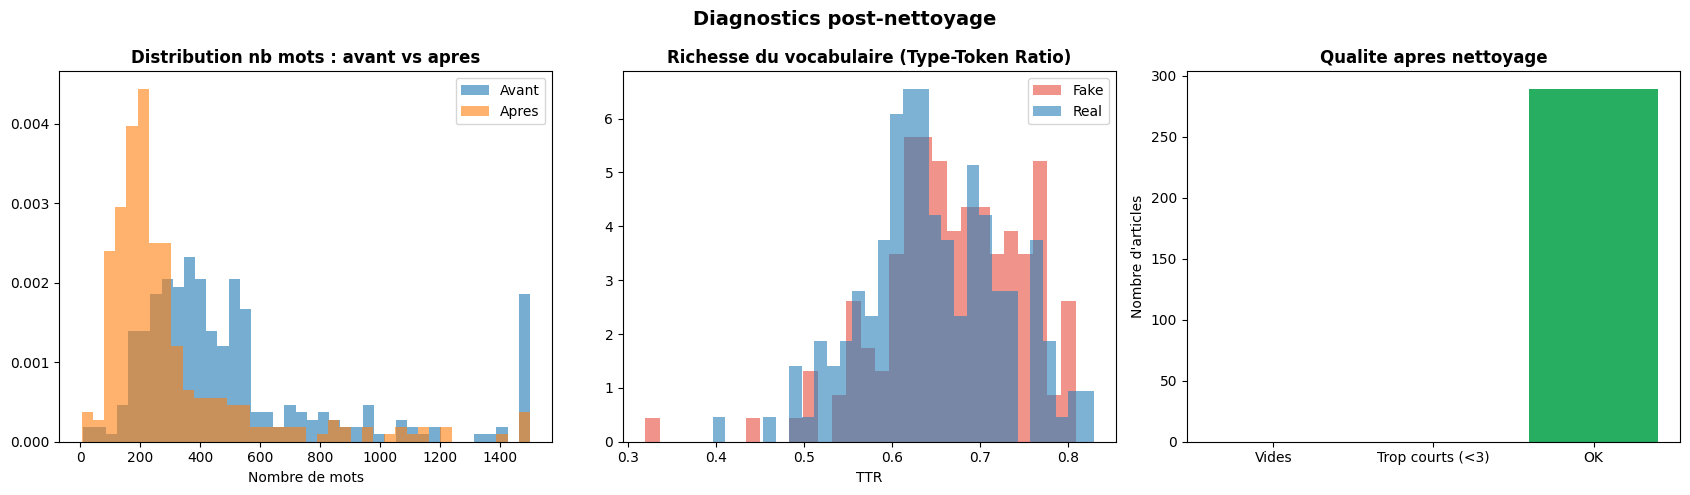

Dataset final : 289 articles
label
1    148
0    141
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for col, name in [("word_count", "Avant"), ("clean_word_count", "Apres")]:
    axes[0].hist(df[col].clip(upper=1500), bins=40, alpha=0.6, label=name, density=True)
axes[0].set_title("Distribution nb mots : avant vs apres", fontweight="bold")
axes[0].set_xlabel("Nombre de mots"); axes[0].legend()

for lbl, color, name in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
    axes[1].hist(df[df["label"] == lbl]["vocab_richness"], bins=30,
                 alpha=0.6, color=color, label=name, density=True)
axes[1].set_title("Richesse du vocabulaire (Type-Token Ratio)", fontweight="bold")
axes[1].set_xlabel("TTR"); axes[1].legend()

empty   = (df["clean"].str.strip() == "").sum()
short   = (df["clean_word_count"] < 3).sum()
bar_data = {"Vides": empty, "Trop courts (<3)": short, "OK": len(df) - empty - short}
axes[2].bar(bar_data.keys(), bar_data.values(), color=["#e74c3c", "#f39c12", "#27ae60"])
axes[2].set_title("Qualite apres nettoyage", fontweight="bold")
axes[2].set_ylabel("Nombre d'articles")

plt.suptitle("Diagnostics post-nettoyage", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

df = df[df["clean_word_count"] >= 3].copy()
df.reset_index(drop=True, inplace=True)
print(f"Dataset final : {len(df):,} articles")
print(df["label"].value_counts())


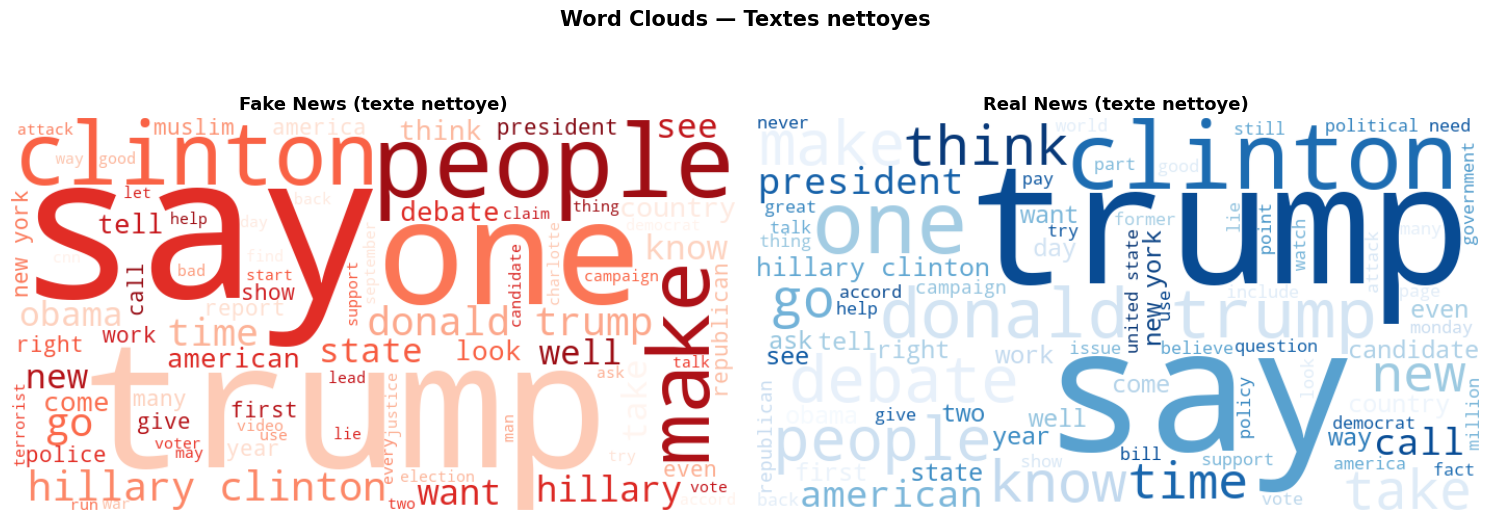

In [9]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, lbl, title, cmap in zip(
    axes, [0, 1],
    ["Fake News (texte nettoye)", "Real News (texte nettoye)"],
    ["Reds", "Blues"]
):
    text = " ".join(df[df["label"] == lbl]["clean"].fillna(""))
    wc = WordCloud(width=700, height=380, background_color="white",
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=13, fontweight="bold"); ax.axis("off")

plt.suptitle("Word Clouds — Textes nettoyes", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()


## 5. Split Train / Test stratifié

In [10]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test, idx_train, idx_test = train_test_split(
    df["clean"], df["label"], df.index,
    test_size=0.2, stratify=df["label"], random_state=SEED
)

print(f"Train : {len(X_train_text):,}  |  Test : {len(X_test_text):,}")
print(f"Distrib. train — Fake: {(y_train==0).sum():,}  |  Real: {(y_train==1).sum():,}")
print(f"Distrib. test  — Fake: {(y_test==0).sum():,}   |  Real: {(y_test==1).sum():,}")
print(f"\nRatio Fake — train: {(y_train==0).mean():.3f}  |  test: {(y_test==0).mean():.3f}")

overlap = set(X_train_text.values) & set(X_test_text.values)
print(f"\nChevauchement train/test (data leakage) : {len(overlap)}")
print("OK Aucun data leakage." if not overlap else "ATTENTION Data leakage detecte !")


Train : 231  |  Test : 58
Distrib. train — Fake: 113  |  Real: 118
Distrib. test  — Fake: 28   |  Real: 30

Ratio Fake — train: 0.489  |  test: 0.483

Chevauchement train/test (data leakage) : 0
OK Aucun data leakage.


## 6. Export du dataset prétraité

In [11]:
PREPROCESSED_CSV = DATA_DIR / "truthguard_preprocessed.csv"

cols = ["statement", "clean", "label",
        "char_count", "word_count", "clean_word_count", "sent_count", "vocab_richness"]
if "source_df" in df.columns:
    cols.insert(3, "source_df")

df_export = df[cols].copy()
df_export["split"] = "train"
df_export.loc[idx_test, "split"] = "test"

df_export.to_csv(PREPROCESSED_CSV, index=False)
print(f"Exporte : {PREPROCESSED_CSV}")
print(f"Dimensions : {df_export.shape}")
print(f"Train : {(df_export['split']=='train').sum():,}  |  Test : {(df_export['split']=='test').sum():,}")
df_export.head(3)


Exporte : C:\Users\PC\fake-news-app\notebook\Fake_news_net\data\truthguard_preprocessed.csv
Dimensions : (289, 10)
Train : 231  |  Test : 58


,statement,clean,label,source_df,char_count,word_count,clean_word_count,sent_count,vocab_richness,split
0,Kaine visits site of Orlando mass shooting Tim...,kaine visit site orlando mass shoot tim kaine ...,1,buzzfeed,1207,200,128,16,0.656250,test
1,Christie among the most unpopular governors in...,christie among unpopular governor country poll...,1,politifact,2033,319,192,20,0.593750,train
2,McAuliffe hangs with Willie Nelson -- and his ...,mcauliffe hang willie nelson weed story highli...,1,buzzfeed,1386,220,127,12,0.700787,train


## 7. Vectorisation TF-IDF

Deux vecteurs combinés :
- **Word n-grams** (1-2) — 10 000 features — `sublinear_tf`
- **Char n-grams** (3-5, `char_wb`) — 5 000 features — robuste aux variations orthographiques


In [12]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

# Word n-grams (1-3) — 20 000 features (élargi vs 10K)
word_tfidf = TfidfVectorizer(
    max_features=20_000, ngram_range=(1, 3), sublinear_tf=True,
    min_df=2, strip_accents="unicode"
)
X_train_word = word_tfidf.fit_transform(X_train_text)
X_test_word  = word_tfidf.transform(X_test_text)

# Char n-grams (2-6, char_wb) — 10 000 features (élargi vs 5K)
char_tfidf = TfidfVectorizer(
    analyzer="char_wb", max_features=10_000, ngram_range=(2, 6),
    sublinear_tf=True, min_df=2
)
X_train_char = char_tfidf.fit_transform(X_train_text)
X_test_char  = char_tfidf.transform(X_test_text)

X_train_tfidf = hstack([X_train_word, X_train_char])
X_test_tfidf  = hstack([X_test_word,  X_test_char])

print(f"TF-IDF v2 (word 1-3 + char 2-6) — Train : {X_train_tfidf.shape} | Test : {X_test_tfidf.shape}")
print(f"  ↑ +15K features vs version originale pour capturer plus de patterns")


TF-IDF v2 (word 1-3 + char 2-6) — Train : (231, 20692) | Test : (58, 20692)
  ↑ +15K features vs version originale pour capturer plus de patterns


## 8. Embeddings sémantiques — SentenceTransformer

Modèle `all-MiniLM-L6-v2` (384 dimensions) : léger, rapide, excellent rapport qualité/taille.  
Les embeddings sont mis en cache (`.npy`) pour éviter de les recalculer.

> **Fix** : masques booléens via `.values` pour compatibilité numpy.


In [13]:
from sentence_transformers import SentenceTransformer

# Modèle v2 : all-mpnet-base-v2 (768 dims) — meilleur que MiniLM-L6 (384 dims)
# Alternative si RAM limitée : "all-MiniLM-L12-v2" (384 dims, plus précis que L6)
EMBED_MODEL_NAME = "all-mpnet-base-v2"
EMBED_CACHE = CACHE_DIR / f"embeddings_{EMBED_MODEL_NAME.replace('/', '_')}.npy"

df_indexed = df.reset_index(drop=True)
df_indexed["split"] = "train"
df_indexed.loc[idx_test, "split"] = "test"
train_mask = df_indexed["split"].eq("train").values
test_mask  = df_indexed["split"].eq("test").values

if EMBED_CACHE.exists():
    print(f"Chargement des embeddings depuis le cache ({EMBED_MODEL_NAME})...")
    X_embeddings_all = np.load(EMBED_CACHE)
else:
    print(f"Calcul des embeddings avec {EMBED_MODEL_NAME} (peut prendre quelques minutes)...")
    print("  → 768 dimensions vs 384 pour all-MiniLM-L6-v2 : +100% de richesse sémantique")
    model_st = SentenceTransformer(EMBED_MODEL_NAME)
    X_embeddings_all = model_st.encode(
        df_indexed["statement"].fillna("").tolist(),
        show_progress_bar=True, batch_size=32
    )
    np.save(EMBED_CACHE, X_embeddings_all)
    print(f"Embeddings sauvegardés : {EMBED_CACHE}")

X_train_emb = X_embeddings_all[train_mask]
X_test_emb  = X_embeddings_all[test_mask]
print(f"Embeddings v2 — Train : {X_train_emb.shape} | Test : {X_test_emb.shape}")


Calcul des embeddings avec all-mpnet-base-v2 (peut prendre quelques minutes)...
  → 768 dimensions vs 384 pour all-MiniLM-L6-v2 : +100% de richesse sémantique


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Embeddings sauvegardés : C:\Users\PC\fake-news-app\notebook\Fake_news_net\data\cache\embeddings_all-mpnet-base-v2.npy
Embeddings v2 — Train : (231, 768) | Test : (58, 768)


## 9. Features combinées TF-IDF + Embeddings

In [17]:
from sklearn.preprocessing import StandardScaler

# Features stylistiques (normalisées)
STYLO_COLS = ["upper_ratio", "upper_word_ratio", "excl_count", "quest_count",
              "digit_ratio", "avg_sent_len", "word_count_raw", "unique_word_ratio"]

train_indices = df_indexed[train_mask].index
test_indices  = df_indexed[test_mask].index

X_train_stylo_raw = df.loc[train_indices, STYLO_COLS].values.astype(float)
X_test_stylo_raw  = df.loc[test_indices,  STYLO_COLS].values.astype(float)

scaler = StandardScaler()
X_train_stylo = scaler.fit_transform(X_train_stylo_raw)
X_test_stylo  = scaler.transform(X_test_stylo_raw)

# Features complètes : TF-IDF + Embeddings + Stylistiques
X_train_full = hstack([X_train_tfidf, csr_matrix(X_train_emb), csr_matrix(X_train_stylo)])
X_test_full  = hstack([X_test_tfidf,  csr_matrix(X_test_emb),  csr_matrix(X_test_stylo)])

print(f"Features v2 (TF-IDF + Emb + Stylo) — Train : {X_train_full.shape} | Test : {X_test_full.shape}")
print(f"  ↑ {X_train_stylo.shape[1]} features stylistiques ajoutées")

FEATURE_SETS = {
    "TF-IDF seul":              (X_train_tfidf, X_test_tfidf),
    "Embeddings seul":          (csr_matrix(X_train_emb), csr_matrix(X_test_emb)),
    "TF-IDF + Embeddings":      (hstack([X_train_tfidf, csr_matrix(X_train_emb)]),
                                  hstack([X_test_tfidf,  csr_matrix(X_test_emb)])),
    "TF-IDF + Embeddings + Stylo": (X_train_full, X_test_full),
}


Features v2 (TF-IDF + Emb + Stylo) — Train : (231, 21468) | Test : (58, 21468)
  ↑ 8 features stylistiques ajoutées


## 10. Export des matrices de features

In [18]:
import scipy.sparse as sp
import numpy as np

# Sauvegarde des matrices sparse pour NB2
sp.save_npz(DATA_DIR / "X_train_full.npz", X_train_full.tocsr())
sp.save_npz(DATA_DIR / "X_test_full.npz",  X_test_full.tocsr())
sp.save_npz(DATA_DIR / "X_train_tfidf.npz", X_train_tfidf.tocsr())
sp.save_npz(DATA_DIR / "X_test_tfidf.npz",  X_test_tfidf.tocsr())

# Sauvegarde des labels et des probas
np.save(DATA_DIR / "y_train.npy", y_train.values)
np.save(DATA_DIR / "y_test.npy",  y_test.values)

print("✅ Matrices exportées :")
print(f"   X_train_full : {X_train_full.shape}")
print(f"   X_test_full  : {X_test_full.shape}")
print(f"   y_train      : {y_train.shape}")
print(f"   y_test       : {y_test.shape}")
print("\n→ Lancer maintenant : TruthGuard_NB2_Modelisation.ipynb")


✅ Matrices exportées :
   X_train_full : (231, 21468)
   X_test_full  : (58, 21468)
   y_train      : (231,)
   y_test       : (58,)

→ Lancer maintenant : TruthGuard_NB2_Modelisation.ipynb


## Résumé Notebook 1

In [16]:
print("=" * 60)
print("  RÉCAPITULATIF — NB1 Préparation des données")
print("=" * 60)
print(f"  Dataset brut          : {n_avant:,} articles")
print(f"  Après nettoyage NLP   : {len(df):,} articles")
print(f"  Train / Test          : {len(X_train_text):,} / {len(X_test_text):,}")
print(f"\n  Dimensions features :")
print(f"   TF-IDF (word+char)   : {X_train_tfidf.shape[1]:,}")
print(f"   Embeddings           : {X_train_emb.shape[1]}")
print(f"   Features stylo       : {X_train_stylo.shape[1]}")
print(f"   TOTAL                : {X_train_full.shape[1]:,}")
print("\n  Fichiers sauvegardés dans data/")
print("  → Prêt pour NB2 Modélisation")
print("=" * 60)


  RÉCAPITULATIF — NB1 Préparation des données
  Dataset brut          : 422 articles
  Après nettoyage NLP   : 289 articles
  Train / Test          : 231 / 58

  Dimensions features :
   TF-IDF (word+char)   : 20,692
   Embeddings           : 768
   Features stylo       : 8
   TOTAL                : 21,468

  Fichiers sauvegardés dans data/
  → Prêt pour NB2 Modélisation
